[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/exorbyte/mbox-cookbook/blob/main/05-explainability/01-reading_field_level_scores.ipynb)

# Reading Field-Level Scores

You have been reading `_score` columns since the first notebook in this cookbook. This notebook explains exactly what those numbers mean, how `APPROX` arrives at a score, why matches sometimes disappear entirely rather than just scoring low, and how `overall_score` combines every field into one number.

In this notebook you will learn:

1. How `APPROX` turns character-level differences into a 0 to 100 score
2. Why matches have a hard cutoff, and why that cutoff depends on field length
3. The exact formula behind `overall_score`
4. How to read every column `include_field_scores=True` and `include_queries=True` add to your results
5. Practical guidelines that follow directly from how scoring actually works

In [ ]:
# !pip install mbox

## 1. How `APPROX` calculates a score

`APPROX` is built on Levenshtein distance, the number of single-character edits (insertions, deletions, substitutions) needed to turn your query into the indexed value. Fewer edits relative to the length of the string produce a higher score; more edits produce a lower one.

The table below shows this directly: the same 13-character word, compared against versions of itself with an increasing number of substituted characters.

In [4]:
import pandas as pd
from mbox.indexing import TableIndexer

def substitute_n(s, n, seed=0):
    """Return a copy of s with exactly n characters substituted, at fixed positions."""
    import random
    random.seed(seed)
    s = list(s)
    positions = random.sample(range(len(s)), n)
    for p in positions:
        s[p] = "Q" if s[p] != "Q" else "Z"
    return "".join(s)

base_word = "APPROXIMATELY"
df = pd.DataFrame({"word": [base_word]})
index = TableIndexer.create_index(df, index_columns=["word"], tmp_dir="tmp_index")

rows = []
for n_edits in range(0, 5):
    query = substitute_n(base_word, n_edits) if n_edits > 0 else base_word
    result = index.match(word=query, include_field_scores=True, min_total_match_value=0)
    score = result["word_score"].iloc[0] if len(result) else None
    rows.append({"edits": n_edits, "query": query, "word_score": score})

pd.DataFrame(rows)

,edits,query,word_score
0,0,APPROXIMATELY,100
1,1,APPROXQMATELY,87
2,2,APPROXQMATELQ,74
3,3,QPPROXQMATELQ,60
4,4,QPPRQXQMATELQ,45


A perfect match scores `100`. Each additional edit lowers the score by roughly the same amount, here, about 13 to 15 points per edit on a 13-character word. This is the core behavior to remember: `APPROX` is measuring edit distance relative to string length, not just counting how many letters happen to overlap.

## A visual comparison: score vs. edit count, across modes

The table in Section 1 showed `APPROX` degrading gradually before hitting its cutoff. It helps to see this next to the other three modes on the same chart, since they behave very differently as edits increase.

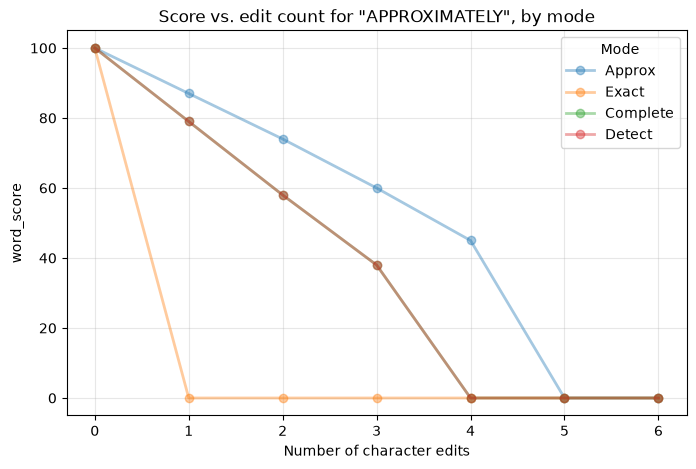

In [ ]:
import matplotlib.pyplot as plt
from mbox.recall import TableRecallMode

base_word = "APPROXIMATELY"
df = pd.DataFrame({"word": [base_word]})
index = TableIndexer.create_index(df, index_columns=["word"], tmp_dir="tmp_index")

modes_to_test = [
    TableRecallMode.APPROX,
    TableRecallMode.EXACT,
    TableRecallMode.COMPLETE,
    TableRecallMode.DETECT
]

max_edits = 6
chart_data = {mode.value: [] for mode in modes_to_test}
edit_counts = list(range(0, max_edits + 1))

for mode in modes_to_test:
    for n_edits in edit_counts:
        query = substitute_n(base_word, n_edits) if n_edits > 0 else base_word
        result = index.match(
            word=query,
            modes={"word": mode},
            include_field_scores=True,
            min_total_match_value=0
        )
        found = len(result) > 0 and result["index_row"].iloc[0] != -1
        score = result["word_score"].iloc[0] if found else 0
        chart_data[mode.value].append(score)

plt.figure(figsize=(8, 5))
for mode_name, scores in chart_data.items():
    plt.plot(edit_counts, scores, marker="o", label=mode_name, alpha=0.4, linewidth=2)

plt.xlabel("Number of character edits")
plt.ylabel("word_score")
plt.title(f'Score vs. edit count for "{base_word}", by mode')
plt.legend(title="Mode")
plt.grid(True, alpha=0.3)
plt.show()

`APPROX` is the only line that slopes downward gradually, it is genuinely measuring degrees of similarity. `EXACT`, `COMPLETE`, and `DETECT` all drop straight to `0` after the very first edit, and stay there. That is the visual version of the distinction from Section 1: `APPROX` gives you a graded signal, the other three modes give you a yes-or-no answer, and no amount of "almost" changes that.

## 2. The hard cutoff: matches disappear, they do not fade to zero

There is a limit to how many edits `APPROX` will tolerate. Past that limit, a candidate is not returned with a low score, it is not returned at all. `index_row` becomes `-1`, and every score column reads `0`.

This limit scales with the length of the field. Short fields have very little room to work with; longer fields have more. The table below shows the maximum number of edits five different words could tolerate before their match disappeared entirely.

In [2]:
test_words = ["CAT", "APPROXIMATE", "APPROXIMATELY", "APPROXIMATIONS", "SUPERCALIFRAGILISTIC"]

rows = []
for word in test_words:
    df = pd.DataFrame({"word": [word]})
    idx = TableIndexer.create_index(df, index_columns=["word"], tmp_dir="tmp_index")
    length = len(word)
    max_found_edits = 0
    for n_edits in range(0, length):
        query = substitute_n(word, n_edits) if n_edits > 0 else word
        result = idx.match(word=query, include_field_scores=True, min_total_match_value=0)
        found = len(result) > 0 and result["index_row"].iloc[0] != -1
        if not found:
            break
        max_found_edits = n_edits
    rows.append({"word": word, "length": length, "max_tolerated_edits": max_found_edits})

pd.DataFrame(rows)

,word,length,max_tolerated_edits
0,CAT,3,0
1,APPROXIMATE,11,3
2,APPROXIMATELY,13,4
3,APPROXIMATIONS,14,5
4,SUPERCALIFRAGILISTIC,20,8


`"CAT"`, three characters long, tolerates zero edits, a single typo loses the match completely. `"SUPERCALIFRAGILISTIC"`, twenty characters long, tolerates eight. Longer fields give `APPROX` more room to work with before hitting its limit.

## 3. How `overall_score` combines fields

When you query more than one field, `overall_score` is the weighted average of each field's individual score:

```
overall_score = floor( (weight_field_1 * score_field_1 / 100) + (weight_field_2 * score_field_2 / 100) + ... )
```

when weights sum to 100. Here it is directly, using a query with two fields and three different weight splits.

In [3]:
df = pd.DataFrame({
    "product_name": ["Extended Battery Pack", "Extended Cell Battery"],
    "description": [
        "Compact accessory offering extended battery life for outdoor gear",
        "Extended battery pack accessory for compact cameras"
    ]
})

index = TableIndexer.create_index(df, index_columns=["product_name", "description"], tmp_dir="tmp_index")

rows = []
for weights in [{"product_name": 50, "description": 50},
                {"product_name": 90, "description": 10},
                {"product_name": 10, "description": 90}]:
    results = index.match(
        product_name="Extended Battery Pack",
        description="Extended Battery Pack",
        weights=weights,
        include_field_scores=True,
        min_total_match_value=0,
        max_results=2
    )
    for _, row in results.iterrows():
        predicted = (row["product_name_score"] * weights["product_name"]
                     + row["description_score"] * weights["description"]) / 100
        rows.append({
            "weights": weights,
            "candidate": row["product_name_candidate"],
            "overall_score": row["overall_score"],
            "name_score": row["product_name_score"],
            "desc_score": row["description_score"],
            "predicted_weighted_avg": round(predicted, 1)
        })

pd.DataFrame(rows)

,weights,candidate,overall_score,name_score,desc_score,predicted_weighted_avg
0,"{'product_name': 50, 'description': 50}",Extended Battery Pack,64,100,29,64.5
1,"{'product_name': 50, 'description': 50}",Extended Cell Battery,64,42,86,64.0
2,"{'product_name': 90, 'description': 10}",Extended Battery Pack,92,100,29,92.9
3,"{'product_name': 90, 'description': 10}",Extended Cell Battery,46,42,86,46.4
4,"{'product_name': 10, 'description': 90}",Extended Cell Battery,81,42,86,81.6
5,"{'product_name': 10, 'description': 90}",Extended Battery Pack,36,100,29,36.1


`predicted_weighted_avg` matches `overall_score` in every row, confirming the formula directly. Once you know this, you can predict how a weight change will affect ranking without running a query first, which is exactly what `04-recall-tuning/02-weighting_fields_for_better_precision.ipynb` relies on.

### Visualizing the crossover

The three weight splits above are just three points along a continuous scale. It's worth seeing the full picture: as weight shifts from fully favoring `description` to fully favoring `product_name`, at what point does the ranking between our two candidates actually flip?

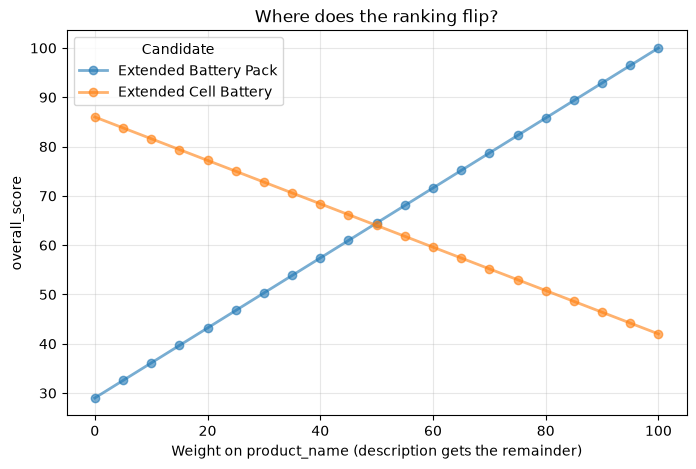

In [9]:
name_weights = list(range(0, 101, 5))

candidate_scores = {
    "Extended Battery Pack": {"name_score": 100, "desc_score": 29},
    "Extended Cell Battery": {"name_score": 42, "desc_score": 86}
}

plt.figure(figsize=(8, 5))
for candidate, scores in candidate_scores.items():
    overall_scores = [
        (scores["name_score"] * w + scores["desc_score"] * (100 - w)) / 100
        for w in name_weights
    ]
    plt.plot(name_weights, overall_scores, marker="o", label=candidate, alpha=0.6, linewidth=2)

plt.xlabel("Weight on product_name (description gets the remainder)")
plt.ylabel("overall_score")
plt.title("Where does the ranking flip?")
plt.legend(title="Candidate")
plt.grid(True, alpha=0.3)
plt.show()

The two lines cross exactly once. To the left of that point, `description` carries more weight and "Extended Cell Battery" ranks higher. To the right, `product_name` carries more weight and "Extended Battery Pack" takes over. Right at the crossing point, the two candidates are tied, which is exactly what you saw at the default 50/50 split earlier: `overall_score = 64` for both.

This is the practical value of knowing `overall_score` is a plain weighted average: the crossover point isn't a mystery you'd have to discover by trial and error, it's just algebra. Given two candidates' field scores, you can solve directly for the weight split where they tie, rather than nudging weights and re-running queries until something changes.

## 4. Every column, explained

`include_field_scores=True` and `include_queries=True` add columns beyond the basics. Here is what each one means:

| Column | Meaning |
|---|---|
| `query_row` | Which row of your input query this result corresponds to |
| `index_row` | Which row of your original indexed data this candidate came from, `-1` if no candidate was found at all |
| `overall_score` | The weighted average of every searched field's score, see Section 3 |
| `<field>_candidate` | The actual value stored in the index for this field |
| `<field>_query` | The raw value you searched with, only present when `include_queries=True` |
| `<field>_score` | This field's individual score, 0 to 100, see Sections 1 and 2 for how it is calculated |

A row with `index_row = -1` means no candidate cleared the internal matching threshold for at least one of the fields you searched, not that a candidate was found and scored poorly. Distinguishing these two cases matters when you are debugging why a query returned nothing, covered next in `02-debugging_a_bad_match.ipynb`.

## 5. Practical guidelines that follow from this

**Do not rely on `APPROX` for very short fields.** A field of three or four characters has almost no room for edits before the cutoff eliminates the match entirely. Initials, short codes, and two-letter abbreviations are usually better matched with `IDENT` or `EXACT`, covered in `04-recall-tuning/01-understanding_match_modes.ipynb`, where a deliberate design choice makes more sense than relying on fuzziness that barely has room to operate.

**Longer fields tolerate more noise, but still have a limit.** If your data is likely to contain heavy noise, OCR errors, garbled scans, transliteration mismatches, consider whether character-level harmonization from `02-data-harmonization/` should reduce that noise before matching, rather than expecting `APPROX` alone to absorb an unlimited amount of it.

**You can calculate the weight split needed to favor one candidate over another.** Since `overall_score` is a confirmed weighted average, if you know two candidates' individual field scores, you can solve directly for the weight split that would rank one above the other, rather than adjusting weights by trial and error.

**`index_row = -1` is a specific, meaningful signal.** It tells you no candidate cleared the threshold for at least one searched field, which is different from "a candidate was found but scored 0." Recognizing this distinction is the first step in diagnosing an unexpectedly empty result, which the next notebook walks through directly.

## Next steps

- **`02-debugging_a_bad_match.ipynb`** - walk through a real match that goes wrong, and use what you just learned to diagnose exactly why

*M|BOX is currently in `beta`. Breaking changes may occur in minor releases until version `1.0.0`.*